# AML Project 1 — ATP Tennis Dataset
## Missing Label Learning with Logistic Lasso Regression (FISTA)
**Advanced Machine Learning · 2026**

---
This notebook covers the full pipeline for the ATP tennis upset-prediction dataset:
- **Task 1** — Data preprocessing and missing-label generation (MCAR / MAR1 / MAR2 / MNAR)
- **Task 2** — FISTA implementation, lambda selection (6 metrics), comparison with sklearn
- **Task 3** — `UnlabeledLogReg` with EM and Label Propagation; experiments under all four schemes

## 0 · Imports & Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# ── Path setup ────────────────────────────────────────────────────────────────
# Works whether launched from notebooks/, atp_tennis/, or the project root.
_cwd = os.getcwd()
if os.path.basename(_cwd) == "notebooks":
    os.chdir("..")          # move to atp_tennis/
sys.path.insert(0, "..")    # project root → imports from common/
sys.path.insert(0, ".")     # atp_tennis/  → scripts/, unlabeled_logreg_atp.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score,
    balanced_accuracy_score, f1_score, average_precision_score,
    recall_score, precision_score,
)

from common.LogisticRegressionFISTA import LogisticRegressionFISTA
from common.FISTASelector import FISTASelector
from common.metrics import Metric, evaluate, print_evaluation
from scripts.missing_data import generate_missing, missingness_summary
from unlabeled_logreg_atp import UnlabeledLogReg

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

RANDOM_STATE = 42
C_MISSING    = 0.3
SCHEMES      = ["MCAR", "MAR1", "MAR2", "MNAR"]
METRICS_T3   = ["Accuracy", "Balanced Accuracy", "F1", "ROC AUC"]

print("All imports OK ✓")
print(f"Working directory: {os.getcwd()}")

All imports OK ✓
Working directory: /Users/ljubomirkolev/Politechnika Warszawska/Advanced Machine Learning/ObfuscatedLogisticRegression/atp_tennis


---
## Task 1 · Data Preparation & Missing-Label Generation

### 1.1 — Preprocessed Dataset

The full preprocessing pipeline (feature engineering, imputation, collinearity removal)
is implemented in `notebooks/01_atp_dataset.ipynb`. Here we load the resulting
`processed/atp_upset.csv`.

**Binary classification target:** `y = 1` if the lower-ranked player (Player B) wins
(an *upset*); `y = 0` if the higher-ranked player wins.

**17 numerical features** (all player-A − player-B differences): ranking stats, serve
percentages, break-point stats, match duration, and average contextual values.

In [2]:
df = pd.read_csv("processed/atp_upset.csv")
feature_names = [c for c in df.columns if c != "y"]
X_all = df[feature_names].values.astype(np.float64)
y_all = df["y"].values.astype(np.float64)

print(f"Dataset shape    : {df.shape}")
print(f"Features         : {len(feature_names)}")
print(f"Positive (upset) : {y_all.mean():.3f}  ({int(y_all.sum()):,} matches)")
print(f"Negative (fav)   : {1-y_all.mean():.3f}  ({int((1-y_all).sum()):,} matches)")
df.head(3)

Dataset shape    : (94131, 18)
Features         : 17
Positive (upset) : 0.502  (47,275 matches)
Negative (fav)   : 0.498  (46,856 matches)


,rank_diff,rank_points_diff,log_rank_ratio,age_diff,height_diff,df_rate_diff,first_in_pct_diff,first_won_pct_diff,second_won_pct_diff,bp_save_pct_diff,hold_pressure_diff,ace_count_diff,svpt_diff,bp_faced_diff,minutes,avg_rank,avg_age,y
0,54.0,2.0,2.944439,-2.4,3.0,-0.010746,-0.079715,-0.000587,-0.087214,-0.250000,-0.233333,-0.010471,0.005236,-0.129032,130.0,29.0,21.9,1
1,229.0,2.0,1.389578,2.8,20.0,0.015794,0.066360,-0.050087,-0.072351,0.400000,0.533333,0.059459,0.091892,0.266667,119.0,189.5,26.0,1
2,13.0,2.0,0.170345,1.8,7.0,-0.014815,-0.042593,0.179599,0.304348,0.499999,-0.875000,0.035088,-0.052632,-0.437500,71.0,75.5,23.9,1


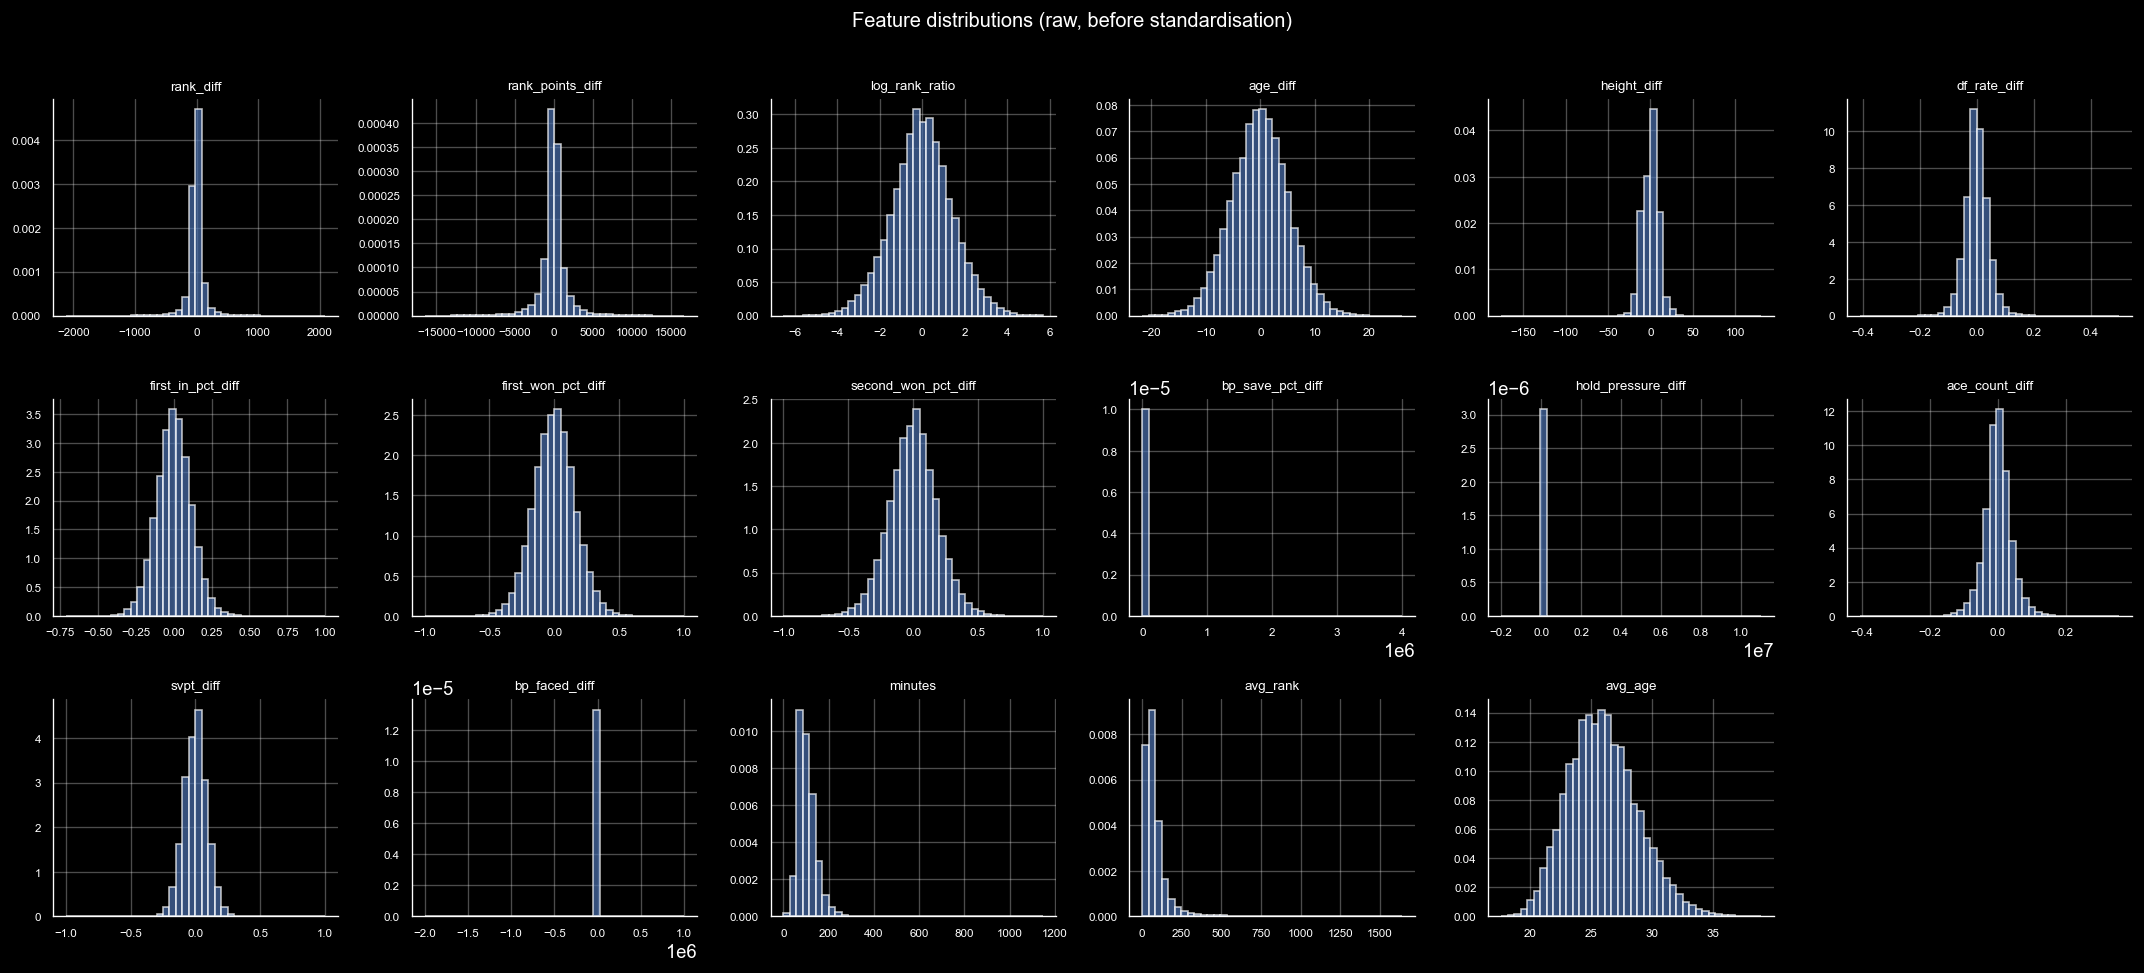

In [3]:
# Feature distribution overview
fig, axes = plt.subplots(3, 6, figsize=(18, 8))
axes = axes.flatten()
for ax, feat in zip(axes, feature_names):
    ax.hist(df[feat], bins=40, color="#4C72B0", alpha=0.7, density=True)
    ax.set_title(feat, fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes[len(feature_names):]:
    ax.set_visible(False)
fig.suptitle("Feature distributions (raw, before standardisation)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

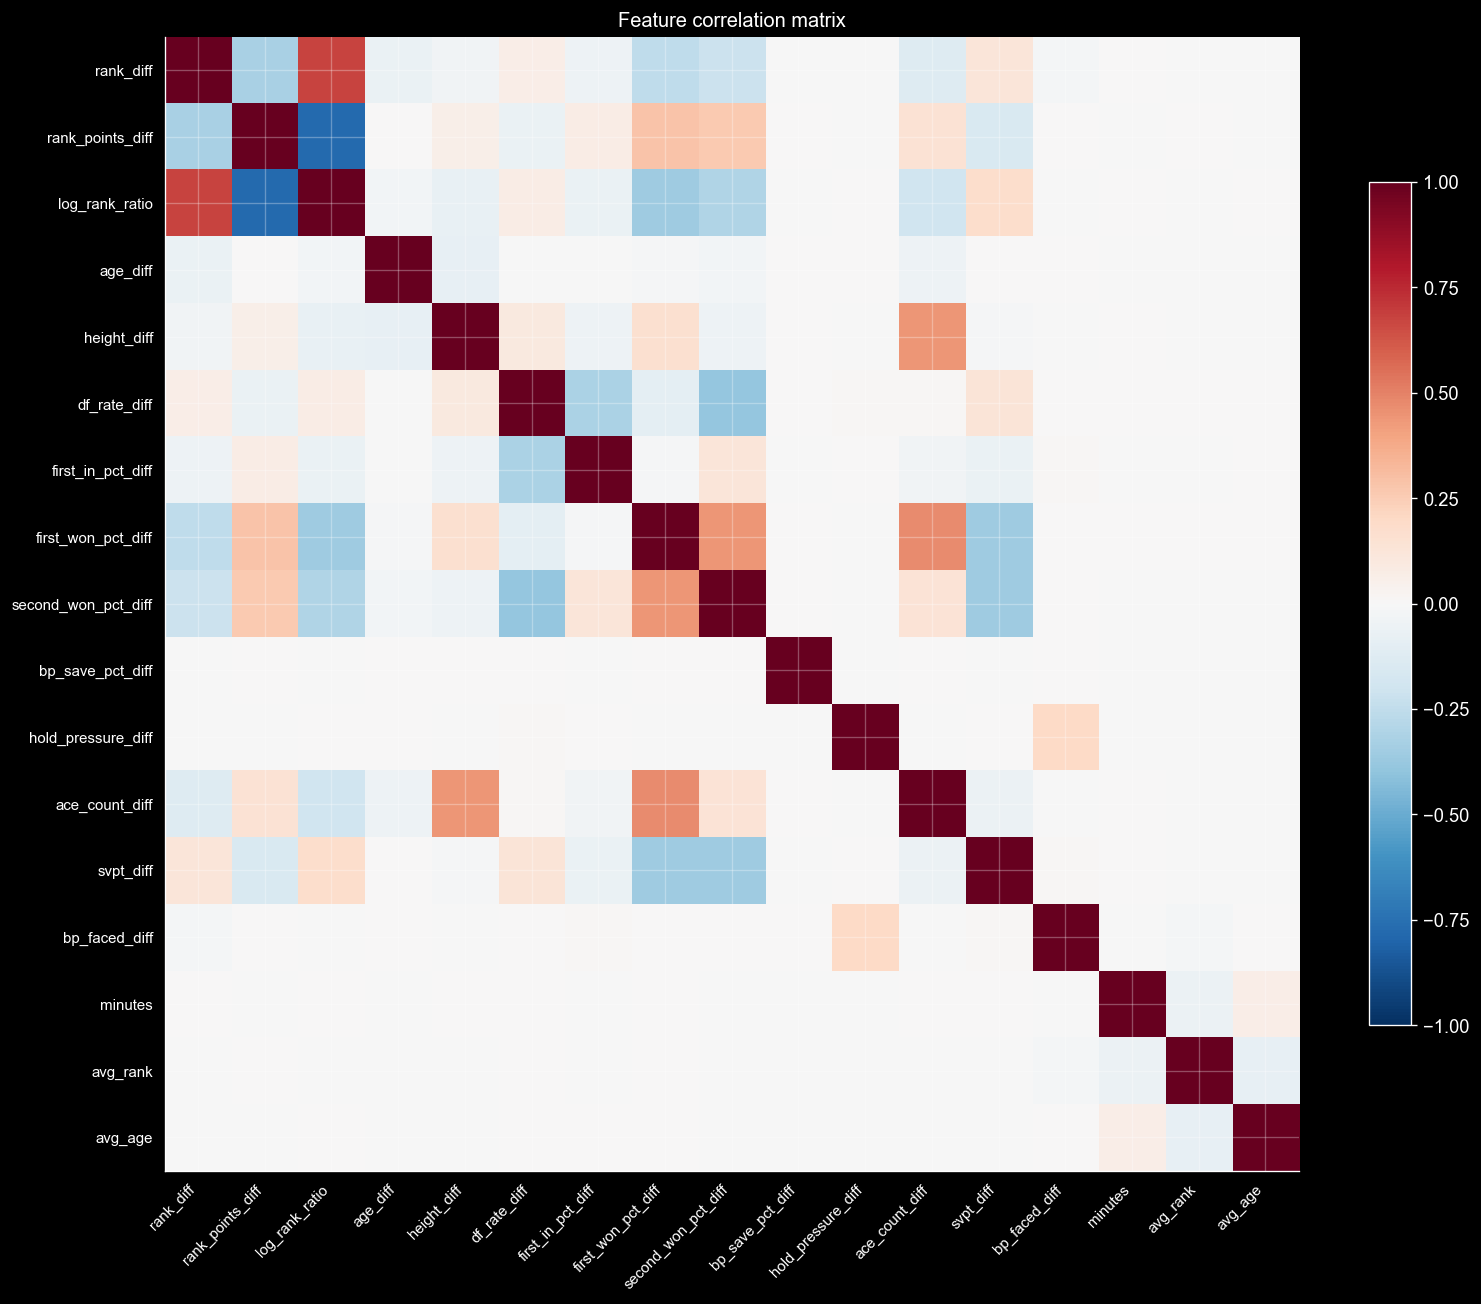

In [4]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(13, 11))
corr = df[feature_names].corr()
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(feature_names, fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("Feature correlation matrix", fontsize=12)
plt.tight_layout()
plt.show()

### 1.2 — Train / Validation / Test Split

In [5]:
X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, stratify=y_tv, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape[0]:7,}  ({y_train.mean():.3f} positive)")
print(f"Val   : {X_val.shape[0]:7,}  ({y_val.mean():.3f} positive)")
print(f"Test  : {X_test.shape[0]:7,}  ({y_test.mean():.3f} positive)")
print()
print("Note: missing labels are applied only to y_train.  y_test is always fully labeled.")

Train :  56,478  (0.502 positive)
Val   :  18,826  (0.502 positive)
Test  :  18,827  (0.502 positive)

Note: missing labels are applied only to y_train.  y_test is always fully labeled.


### 1.3 — Missing-Label Generation Schemes

Four schemes are applied to the **training labels only** (test set is always fully observed).

| Scheme | Mechanism | Math |
|--------|-----------|------|
| **MCAR** | Completely at random | P(S=1 \| X, Y) = c |
| **MAR1** | Depends on a single feature X_j (highest \|corr(X_j, Y)\|) | P(S=1 \| X, Y) = σ(α · X_j + b) |
| **MAR2** | Depends on all features via random linear combination | P(S=1 \| X, Y) = σ(w⊤X + b) |
| **MNAR** | Depends on features **and** the true label Y | P(S=1 \| X, Y) = σ(w⊤X + γ·Y + b) |

The intercept *b* is calibrated by bisection so the overall missing rate equals *c*.

In [6]:
X_df_train = pd.DataFrame(X_train, columns=feature_names)

print(f"Target missing rate: c = {C_MISSING}\n")
scheme_results = {}
for scheme in SCHEMES:
    _, y_obs, probs = generate_missing(
        scheme=scheme, X=X_df_train, y=y_train,
        missing_rate=C_MISSING, random_state=RANDOM_STATE,
    )
    info = missingness_summary(y_train, y_obs)
    scheme_results[scheme] = {"y_obs": y_obs, "probs": probs, "info": info}
    print(f"{scheme:5s}: missing={info['n_missing']:,} ({info['missing_rate']:.1%})  "
          f"| class-0 missing={info['missing_rate_class0']:.1%}  "
          f"| class-1 missing={info['missing_rate_class1']:.1%}")

Target missing rate: c = 0.3

MCAR : missing=17,019 (30.1%)  | class-0 missing=30.2%  | class-1 missing=30.1%
MAR1 : missing=17,051 (30.2%)  | class-0 missing=17.9%  | class-1 missing=42.4%
MAR2 : missing=16,893 (29.9%)  | class-0 missing=33.0%  | class-1 missing=26.8%
MNAR : missing=16,928 (30.0%)  | class-0 missing=15.9%  | class-1 missing=43.9%


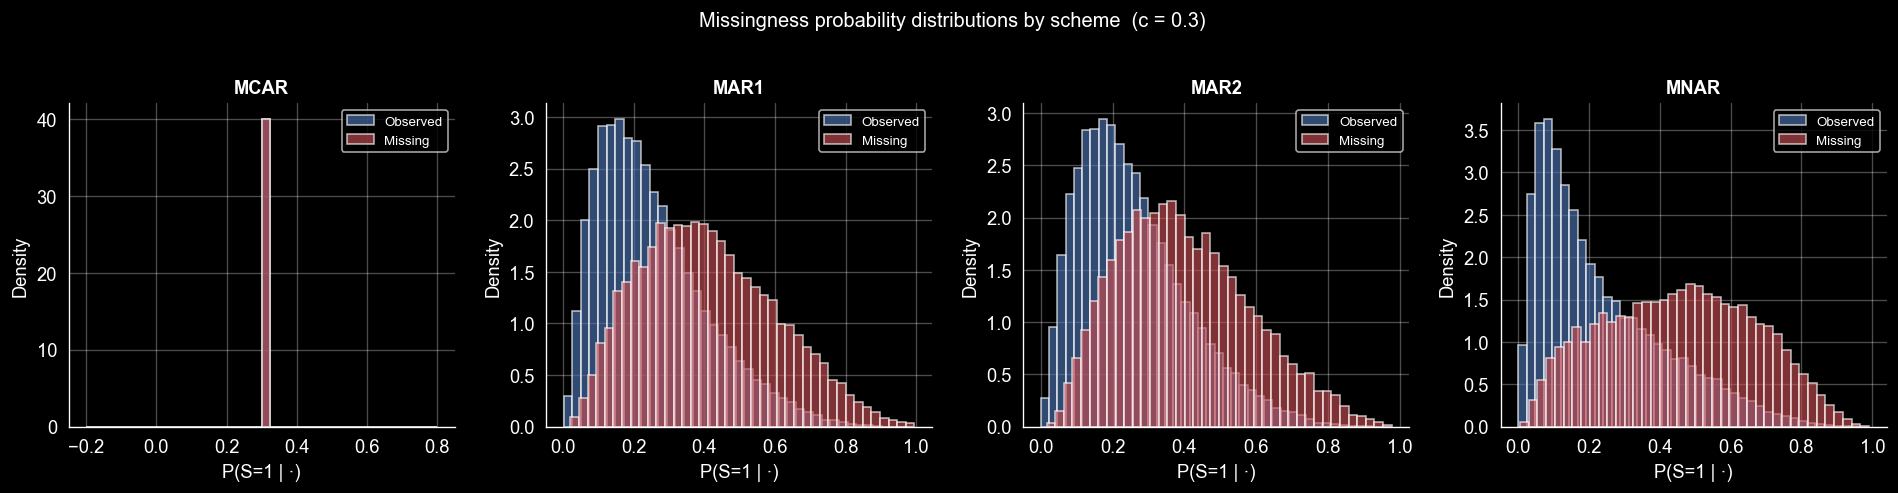

In [7]:
# Visualise per-observation missingness probabilities per scheme
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, scheme in zip(axes, SCHEMES):
    probs = scheme_results[scheme]["probs"]
    y_obs = scheme_results[scheme]["y_obs"]
    observed = y_obs != -1

    ax.hist(probs[observed],  bins=40, alpha=0.65, density=True,
            color="#4C72B0", label="Observed")
    ax.hist(probs[~observed], bins=40, alpha=0.65, density=True,
            color="#C44E52", label="Missing")
    ax.set_title(scheme, fontsize=11, fontweight="bold")
    ax.set_xlabel("P(S=1 | ·)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

fig.suptitle(f"Missingness probability distributions by scheme  (c = {C_MISSING})",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# Per-class missing rates — key diagnostic: MNAR should differ between classes
comparison = pd.DataFrame({
    scheme: {
        "Overall missing rate": scheme_results[scheme]["info"]["missing_rate"],
        "Class-0 missing rate": scheme_results[scheme]["info"]["missing_rate_class0"],
        "Class-1 missing rate": scheme_results[scheme]["info"]["missing_rate_class1"],
    }
    for scheme in SCHEMES
}).T.round(3)

display(comparison)

# In MCAR/MAR1/MAR2 the per-class rates should be similar.
# In MNAR they should differ noticeably — that's the whole point.

,Overall missing rate,Class-0 missing rate,Class-1 missing rate
MCAR,0.301,0.302,0.301
MAR1,0.302,0.179,0.424
MAR2,0.299,0.330,0.268
MNAR,0.300,0.159,0.439


---
## Task 2 · FISTA — Custom L1-Regularised Logistic Regression

### 2.1 — Algorithm Overview

FISTA minimises the Logistic Lasso objective:

$$\min_w \; \frac{1}{n}\sum_{i=1}^n \ell(y_i, w^\top x_i) \;+\; \lambda \|w_{1:}\|_1$$

where $\ell$ is the binary cross-entropy loss and the bias $w_0$ is **not** penalised.

**Three key ingredients:**
1. **Lipschitz step size** $1/L$, where $L = \|X\|_F^2 / 4n$ (exact for logistic loss).
2. **Soft-thresholding** (proximal operator of L1): $S_\alpha(v) = \text{sign}(v)\cdot\max(|v|-\alpha,0)$.
3. **Nesterov momentum**: $t_{k+1} = (1+\sqrt{1+4t_k^2})/2$ → $O(1/k^2)$ convergence rate.

**Feature standardisation** is mandatory: FISTA's step size depends on $\|X\|_F^2$;
raw ATP features span orders of magnitude (ranking diffs ≫ percentage diffs), so we
fit a `StandardScaler` on the training set only (no data leakage).

### 2.2 — Standardise Features

In [9]:
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Feature scaling (StandardScaler):")
print(f"  Mean of train after scaling: {X_train_s.mean():.2e}  (should be ~0)")
print(f"  Std  of train after scaling: {X_train_s.std():.4f}   (should be ~1)")

Feature scaling (StandardScaler):
  Mean of train after scaling: -6.09e-16  (should be ~0)
  Std  of train after scaling: 1.0000   (should be ~1)


### 2.3 — Lambda Selection

`FISTASelector` trains one FISTA model per lambda value and selects the best by the
chosen evaluation metric on the validation set.

**Available metrics** (user-selectable): Recall, Precision, F1, Balanced Accuracy,
ROC AUC, PR AUC. We demo all six below, then use ROC AUC for the main experiments.

In [10]:
lambdas = np.logspace(-4, 1, 30)

# Demo: run FISTASelector for every metric and show the chosen lambda
print(f"{'Metric':<22}  {'Best lambda':>12}  {'Val score':>10}")
print("-" * 50)

best_by_metric = {}
for metric in Metric:
    sel = FISTASelector(lambdas=lambdas, max_iter=1000, tol=1e-4)
    sel.fit(X_train_s, y_train, X_val_s, y_val, measure=metric)
    best_by_metric[metric] = sel
    print(f"{metric.name:<22}  {sel.best_lambda:>12.6f}  {sel.scores[sel.best_lambda]:>10.4f}")

# Use ROC AUC as the primary criterion
selector = best_by_metric[Metric.AUC_ROC]
BEST_LAMBDA = selector.best_lambda
print(f"\n→ Using lambda = {BEST_LAMBDA:.6f}  (selected by ROC AUC)")

Metric                   Best lambda   Val score
--------------------------------------------------
RECALL                      0.417532      1.0000
PRECISION                   0.001610      0.9373
F_MEASURE                   0.001083      0.9399
BALANCED_ACCURACY           0.000728      0.9394
AUC_ROC                     0.000221      0.9865
AUC_PR                      0.000149      0.9861

→ Using lambda = 0.000221  (selected by ROC AUC)


### 2.4 — Validation Metric vs λ

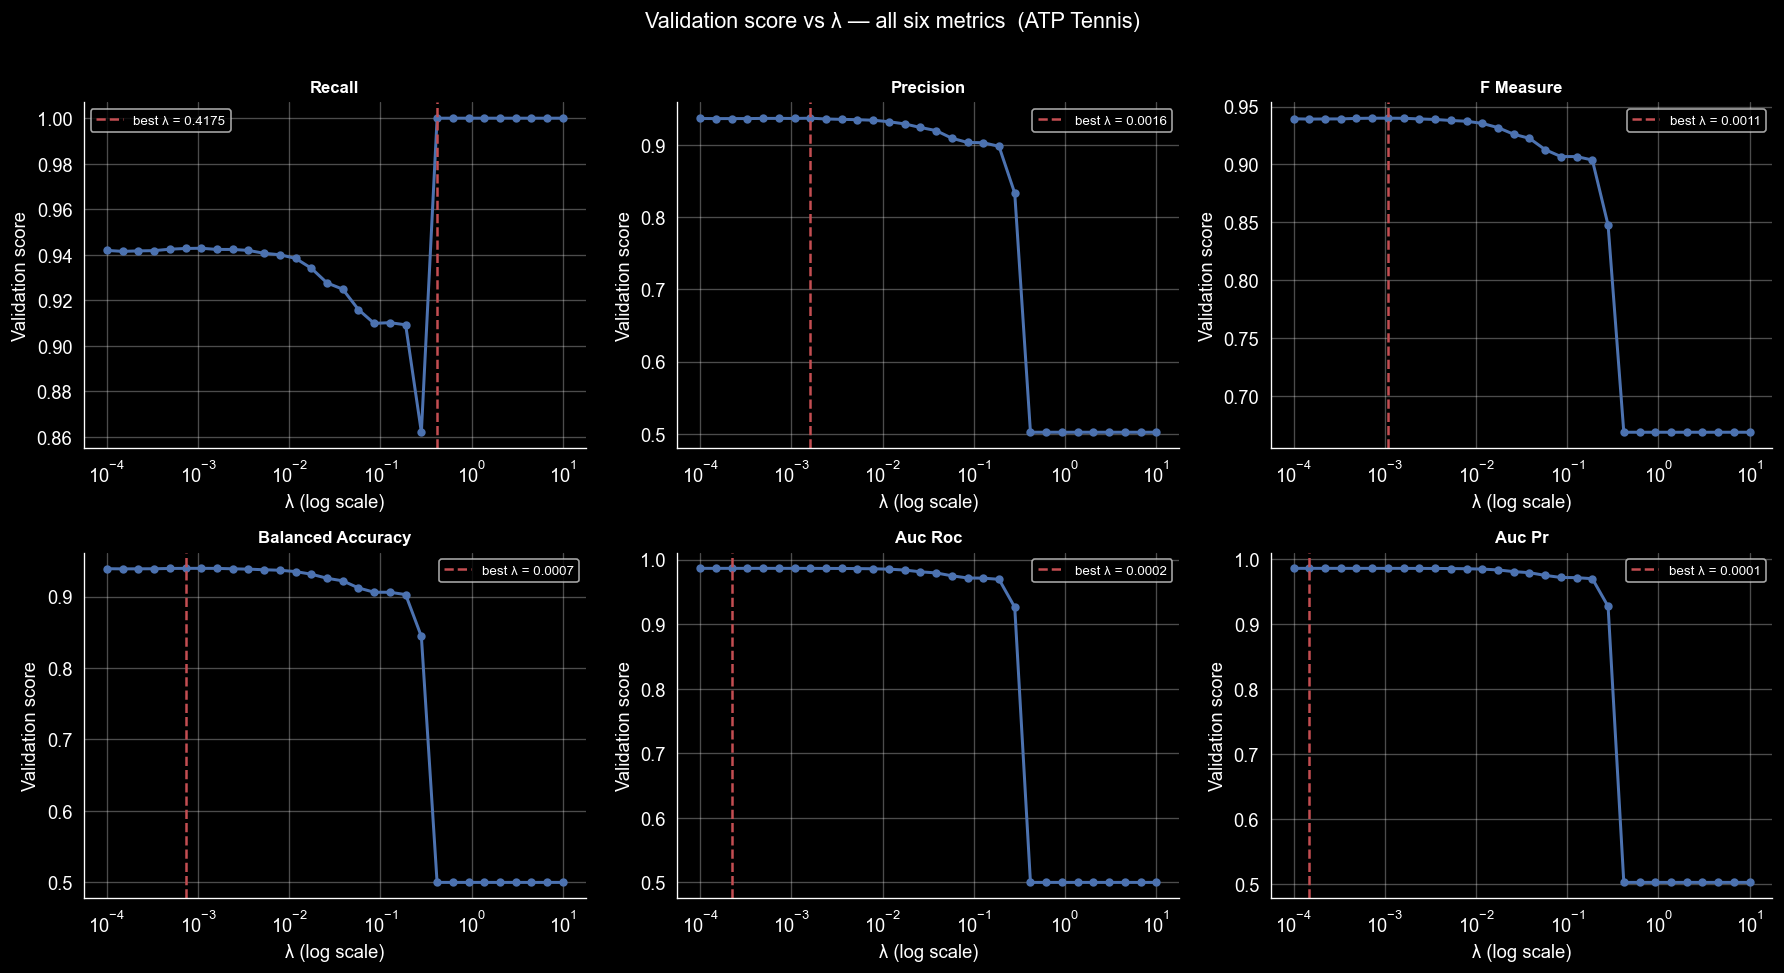

In [11]:
# Show metric vs lambda curves for all 6 metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (metric, sel) in zip(axes, best_by_metric.items()):
    scores = [sel.scores[l] for l in lambdas]
    ax.semilogx(lambdas, scores, "o-", color="#4C72B0", linewidth=1.8, markersize=4)
    ax.axvline(sel.best_lambda, color="#C44E52", linestyle="--",
               label=f"best λ = {sel.best_lambda:.4f}")
    ax.set_title(metric.name.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel("λ (log scale)")
    ax.set_ylabel("Validation score")
    ax.legend(fontsize=8)

fig.suptitle("Validation score vs λ — all six metrics  (ATP Tennis)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 2.5 — Regularisation Path (Coefficient Values vs λ)

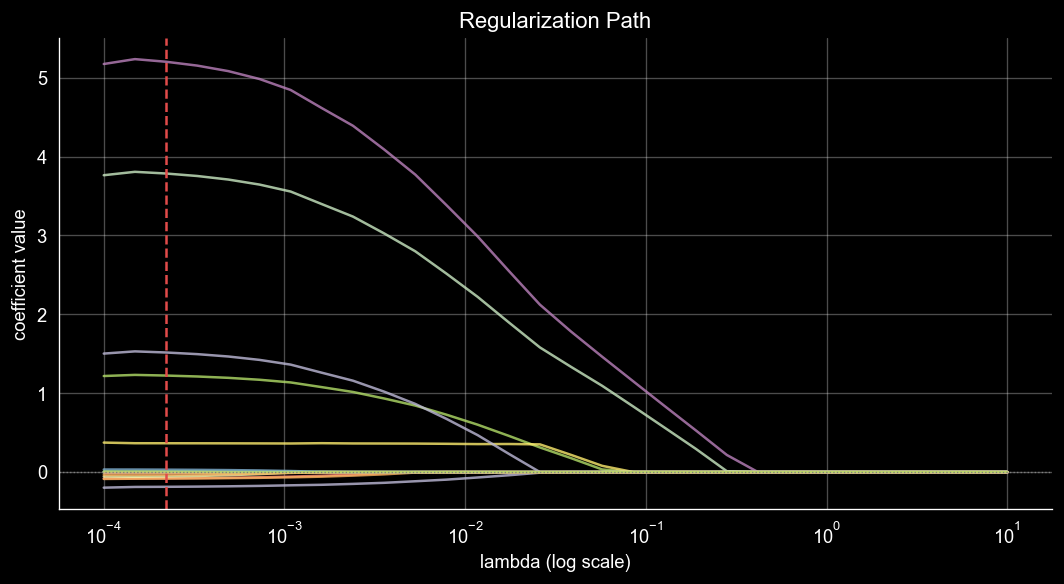

In [12]:
# Regularisation path using the ROC-AUC-selected FISTASelector
selector.plot_coefficients(feature_names=feature_names)

### 2.6 — FISTA vs sklearn L1 Logistic Regression

In [13]:
# sklearn uses C = 1 / (n_train * lambda)
C_sklearn = 1.0 / (X_train_s.shape[0] * BEST_LAMBDA)
sk_model = LogisticRegression(
    penalty="l1", solver="saga", C=C_sklearn,
    max_iter=3000, random_state=RANDOM_STATE,
)
sk_model.fit(X_train_s, y_train)

fista_proba  = selector.predict_proba(X_test_s)
sklearn_proba = sk_model.predict_proba(X_test_s)[:, 1]
fista_pred   = (fista_proba  >= 0.5).astype(int)
sklearn_pred  = (sklearn_proba >= 0.5).astype(int)

def all_metrics(y_true, y_pred, y_proba):
    return {
        "Recall":            recall_score(y_true, y_pred, zero_division=0),
        "Precision":         precision_score(y_true, y_pred, zero_division=0),
        "F1":                f1_score(y_true, y_pred, zero_division=0),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "ROC AUC":           roc_auc_score(y_true, y_proba),
        "PR AUC":            average_precision_score(y_true, y_proba),
    }

t2_results = pd.DataFrame({
    "FISTA (custom)": all_metrics(y_test, fista_pred,   fista_proba),
    "sklearn L1":     all_metrics(y_test, sklearn_pred, sklearn_proba),
}).round(4)

print(f"Best λ (FISTA) = {BEST_LAMBDA:.6f}   C_sklearn = {C_sklearn:.4f}\n")
display(t2_results)

Best λ (FISTA) = 0.000221   C_sklearn = 0.0800



,FISTA (custom),sklearn L1
Recall,0.9438,0.9441
Precision,0.9398,0.9395
F1,0.9418,0.9418
Balanced Accuracy,0.9414,0.9413
ROC AUC,0.9866,0.9866
PR AUC,0.9857,0.9857


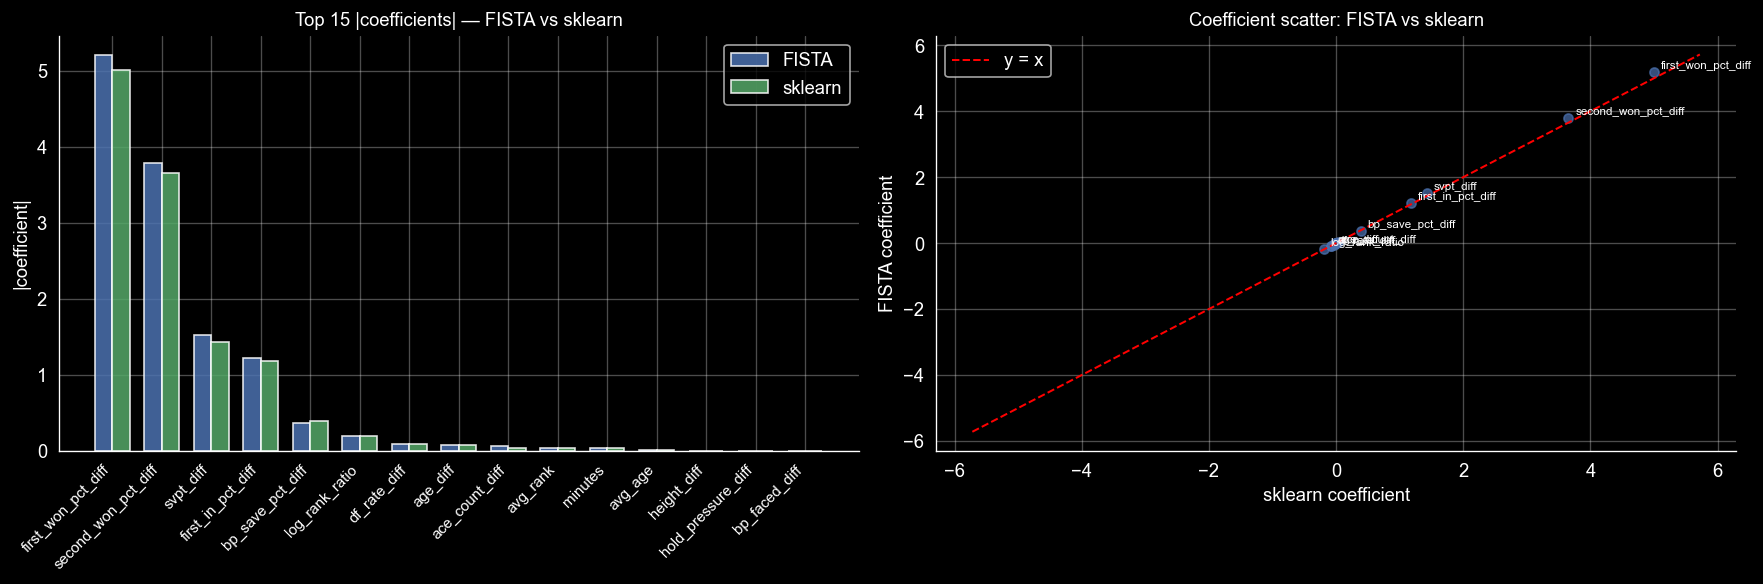

Zero coefficients — FISTA: 5/17   sklearn: 5/17
Bias (FISTA): 0.0332


In [14]:
fista_coef   = selector.best_model.w[1:]   # w[0] = bias
sklearn_coef  = sk_model.coef_[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar — top features by |FISTA coef|
idx = np.argsort(np.abs(fista_coef))[::-1][:15]
x, w = np.arange(len(idx)), 0.35
axes[0].bar(x - w/2, np.abs(fista_coef[idx]),   w, label="FISTA",   color="#4C72B0", alpha=0.85)
axes[0].bar(x + w/2, np.abs(sklearn_coef[idx]),  w, label="sklearn", color="#55A868", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([feature_names[i] for i in idx], rotation=45, ha="right", fontsize=9)
axes[0].set_title("Top 15 |coefficients| — FISTA vs sklearn", fontsize=11)
axes[0].legend()
axes[0].set_ylabel("|coefficient|")

# Scatter
lim = max(np.abs(np.concatenate([fista_coef, sklearn_coef]))) * 1.1
axes[1].scatter(sklearn_coef, fista_coef, s=30, alpha=0.7, color="#4C72B0")
axes[1].plot([-lim, lim], [-lim, lim], "r--", linewidth=1.2, label="y = x")
for i, fn in enumerate(feature_names):
    if abs(fista_coef[i]) > 0.05:
        axes[1].annotate(fn, (sklearn_coef[i], fista_coef[i]),
                         fontsize=7, xytext=(4, 2), textcoords="offset points")
axes[1].set_xlabel("sklearn coefficient")
axes[1].set_ylabel("FISTA coefficient")
axes[1].set_title("Coefficient scatter: FISTA vs sklearn", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

n_zero_f  = int((np.abs(fista_coef)  < 1e-6).sum())
n_zero_sk = int((np.abs(sklearn_coef) < 1e-6).sum())
print(f"Zero coefficients — FISTA: {n_zero_f}/{len(feature_names)}   "
      f"sklearn: {n_zero_sk}/{len(feature_names)}")
print(f"Bias (FISTA): {selector.best_model.w[0]:.4f}")

---
## Task 3 · UnlabeledLogReg — Semi-Supervised FISTA

### 3.1 — Methodology

`UnlabeledLogReg` uses **both** labeled (Y ∈ {0,1}) and unlabeled (Y = −1) observations.
The user selects one of two label-completion algorithms:

**Algorithm 1 — EM (Expectation–Maximisation)**
1. *Initialise*: train FISTA on labeled rows only → predict soft P(Y=1|X) for unlabeled.
2. *M-step*: refit FISTA on all observations using soft labels for unlabeled.
3. *E-step*: update soft labels with new model predictions.
4. Repeat until max|Δp| < tol (or max_iter reached) → threshold at 0.5 → final FISTA.

**Algorithm 2 — Label Propagation** (graph-based, one-shot)
1. Build a *k*-NN graph over all *n* training points; symmetrise.
2. Gaussian kernel: $w_{ij} = e^{-d_{ij}^2/\sigma^2}$, where σ = median distance.
3. Row-normalise → transition matrix W; partition into labeled/unlabeled blocks.
4. Solve closed form: $f_u = (I - W_{uu})^{-1} W_{ul} f_l$ using a **sparse direct solver**.
5. Threshold at 0.5 → hard labels → fit FISTA.

**Three comparison methods:**
| Method | Description |
|--------|-------------|
| **Naive** | FISTA trained only on rows where Y is observed (S=0) |
| **EM / Label Prop** | Semi-supervised completion + FISTA |
| **Oracle** | FISTA trained on *all* rows with their *true* labels (upper bound) |

### 3.2 — Experiment 1: Four Missing Schemes at c = 0.3

In [15]:
results_em = {}
results_lp = {}

for scheme in SCHEMES:
    print(f"\n{'='*55}")
    print(f"  Scheme: {scheme}   (c = {C_MISSING})")
    print(f"{'='*55}")
    _, y_obs, _ = generate_missing(
        scheme=scheme, X=pd.DataFrame(X_train_s, columns=feature_names),
        y=y_train, missing_rate=C_MISSING, random_state=RANDOM_STATE,
    )
    n_miss = int((y_obs == -1).sum())
    print(f"  Missing: {n_miss}/{len(y_obs)} ({n_miss/len(y_obs):.1%})")

    for tag, method, store in [("EM", "em", results_em), ("Label Prop", "label_propagation", results_lp)]:
        model = UnlabeledLogReg(
            method=method, lambda_val=BEST_LAMBDA,
            max_iter=20, tol=1e-4, fista_max_iter=1000,
            n_neighbors=10, random_state=RANDOM_STATE,
        )
        model.naive_fit(X_train_s, y_obs)
        model.oracle_fit(X_train_s, y_train)
        model.fit(X_train_s, y_obs)

        naive_s  = model._metrics(y_test, model.model_naive_.predict_proba(X_test_s))
        ulr_s    = model._metrics(y_test, model.predict_proba(X_test_s))
        oracle_s = model._metrics(y_test, model.model_oracle_.predict_proba(X_test_s))

        method_label = "EM" if tag == "EM" else "Label Prop"
        store[scheme] = {
            "Naive": naive_s, method_label: ulr_s, "Oracle": oracle_s,
            "model": model,
        }
        print(f"  [{tag:10s}] Naive={naive_s['ROC AUC']:.4f}  "
              f"{tag}={ulr_s['ROC AUC']:.4f}  Oracle={oracle_s['ROC AUC']:.4f}")


  Scheme: MCAR   (c = 0.3)
  Missing: 17019/56478 (30.1%)
    [EM] converged at iteration 5  (Δ=4.41e-05)
  [EM        ] Naive=0.9866  EM=0.9866  Oracle=0.9866
  [Label Prop] Naive=0.9866  Label Prop=0.9862  Oracle=0.9866

  Scheme: MAR1   (c = 0.3)
  Missing: 17051/56478 (30.2%)
    [EM] converged at iteration 5  (Δ=5.17e-05)
  [EM        ] Naive=0.9866  EM=0.9866  Oracle=0.9866
  [Label Prop] Naive=0.9866  Label Prop=0.9862  Oracle=0.9866

  Scheme: MAR2   (c = 0.3)
  Missing: 16893/56478 (29.9%)
    [EM] converged at iteration 5  (Δ=6.80e-05)
  [EM        ] Naive=0.9866  EM=0.9866  Oracle=0.9866
  [Label Prop] Naive=0.9866  Label Prop=0.9858  Oracle=0.9866

  Scheme: MNAR   (c = 0.3)
  Missing: 16928/56478 (30.0%)
    [EM] converged at iteration 5  (Δ=5.79e-05)
  [EM        ] Naive=0.9865  EM=0.9865  Oracle=0.9866
  [Label Prop] Naive=0.9865  Label Prop=0.9847  Oracle=0.9866


In [16]:
# Format results as DataFrames
def to_df(store, method_label):
    rows = []
    for scheme in SCHEMES:
        for mname, scores in store[scheme].items():
            if mname == "model":
                continue
            rows.append({"Scheme": scheme, "Method": mname, **scores})
    return pd.DataFrame(rows).set_index(["Scheme", "Method"])

df_em = to_df(results_em, "EM")
df_lp = to_df(results_lp, "Label Prop")

print("=== EM Results ===")
display(df_em.round(4))
print("\n=== Label Propagation Results ===")
display(df_lp.round(4))

=== EM Results ===


Accuracy  Balanced Accuracy      F1  ROC AUC
Scheme Method                                              
MCAR   Naive     0.9415             0.9415  0.9419   0.9866
       EM        0.9414             0.9413  0.9418   0.9866
       Oracle    0.9414             0.9414  0.9418   0.9866
MAR1   Naive     0.9416             0.9416  0.9420   0.9866
       EM        0.9416             0.9416  0.9420   0.9866
       Oracle    0.9414             0.9414  0.9418   0.9866
MAR2   Naive     0.9414             0.9414  0.9417   0.9866
       EM        0.9414             0.9414  0.9417   0.9866
       Oracle    0.9414             0.9414  0.9418   0.9866
MNAR   Naive     0.9360             0.9361  0.9349   0.9865
       EM        0.9376             0.9377  0.9368   0.9865
       Oracle    0.9414             0.9414  0.9418   0.9866


=== Label Propagation Results ===


Accuracy  Balanced Accuracy      F1  ROC AUC
Scheme Method                                                  
MCAR   Naive         0.9415             0.9415  0.9419   0.9866
       Label Prop    0.9397             0.9397  0.9402   0.9862
       Oracle        0.9414             0.9414  0.9418   0.9866
MAR1   Naive         0.9416             0.9416  0.9420   0.9866
       Label Prop    0.9395             0.9395  0.9398   0.9862
       Oracle        0.9414             0.9414  0.9418   0.9866
MAR2   Naive         0.9414             0.9414  0.9417   0.9866
       Label Prop    0.9389             0.9389  0.9392   0.9858
       Oracle        0.9414             0.9414  0.9418   0.9866
MNAR   Naive         0.9360             0.9361  0.9349   0.9865
       Label Prop    0.9271             0.9273  0.9246   0.9847
       Oracle        0.9414             0.9414  0.9418   0.9866

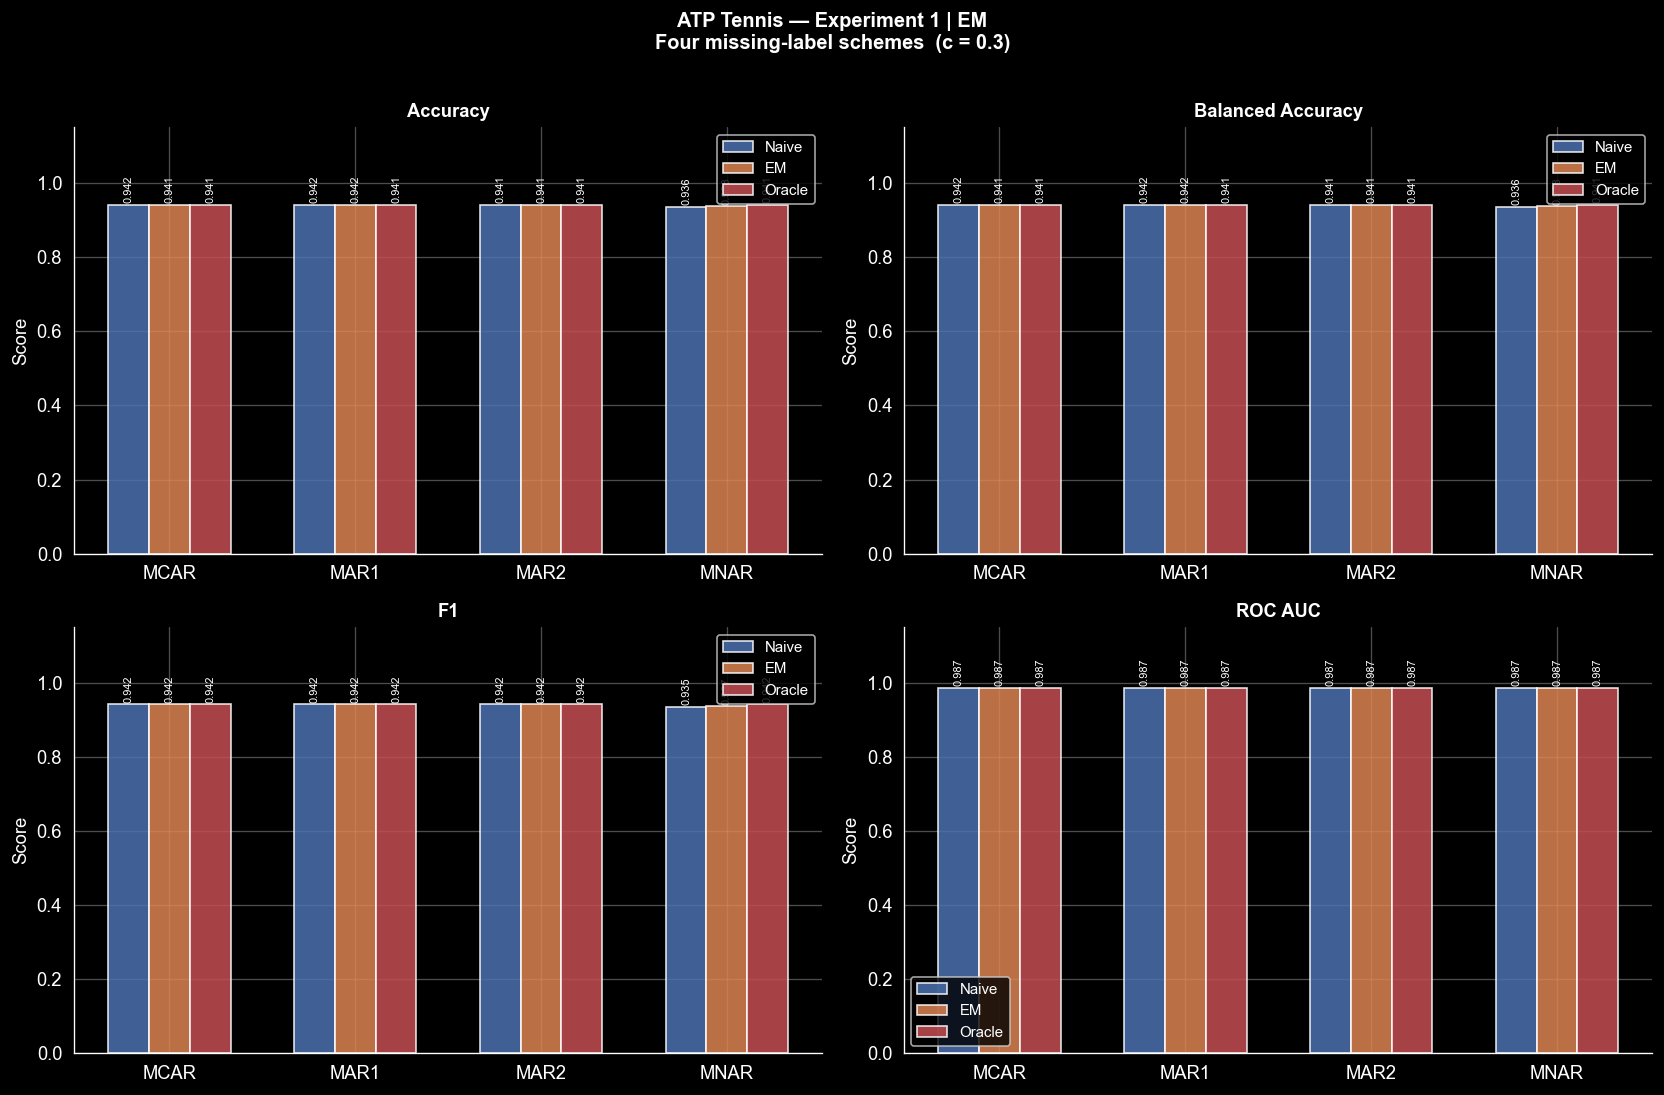

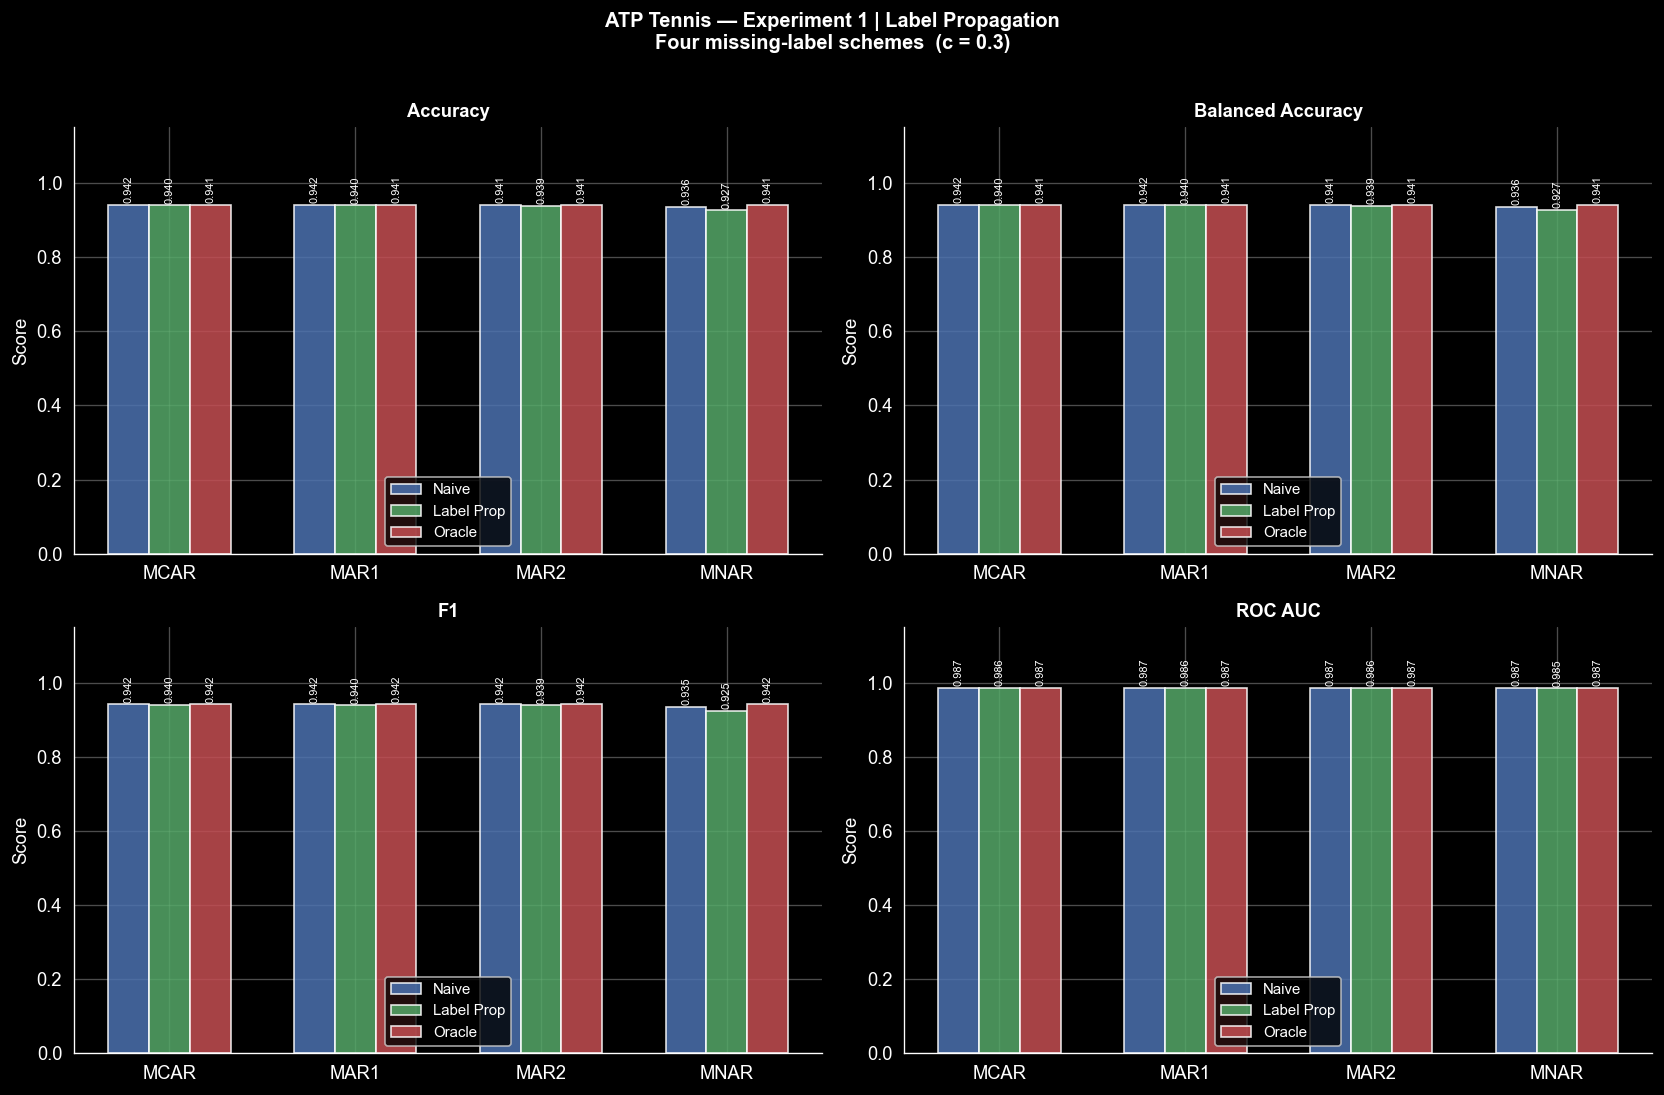

In [17]:
# Grouped bar charts: 4 metrics × 4 schemes, one figure per method
PALETTE = {"Naive": "#4C72B0", "EM": "#DD8452", "Label Prop": "#55A868", "Oracle": "#C44E52"}

def plot_scheme_bars(df, method_label, title):
    methods = [m for m in ["Naive", method_label, "Oracle"]
               if m in df.index.get_level_values("Method").unique()]
    x = np.arange(4)
    width = 0.22
    offsets = np.linspace(-(len(methods)-1)/2, (len(methods)-1)/2, len(methods)) * width

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()
    for ax, metric in zip(axes, METRICS_T3):
        for offset, mname in zip(offsets, methods):
            vals = [df.loc[(s, mname), metric] for s in SCHEMES]
            bars = ax.bar(x + offset, vals, width, label=mname,
                          color=PALETTE[mname], alpha=0.85, edgecolor="white")
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=6.5, rotation=90)
        ax.set_title(metric, fontsize=11, fontweight="bold")
        ax.set_xticks(x); ax.set_xticklabels(SCHEMES)
        ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
        ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout(); plt.show()

plot_scheme_bars(df_em, "EM",
    f"ATP Tennis — Experiment 1 | EM\nFour missing-label schemes  (c = {C_MISSING})")
plot_scheme_bars(df_lp, "Label Prop",
    f"ATP Tennis — Experiment 1 | Label Propagation\nFour missing-label schemes  (c = {C_MISSING})")

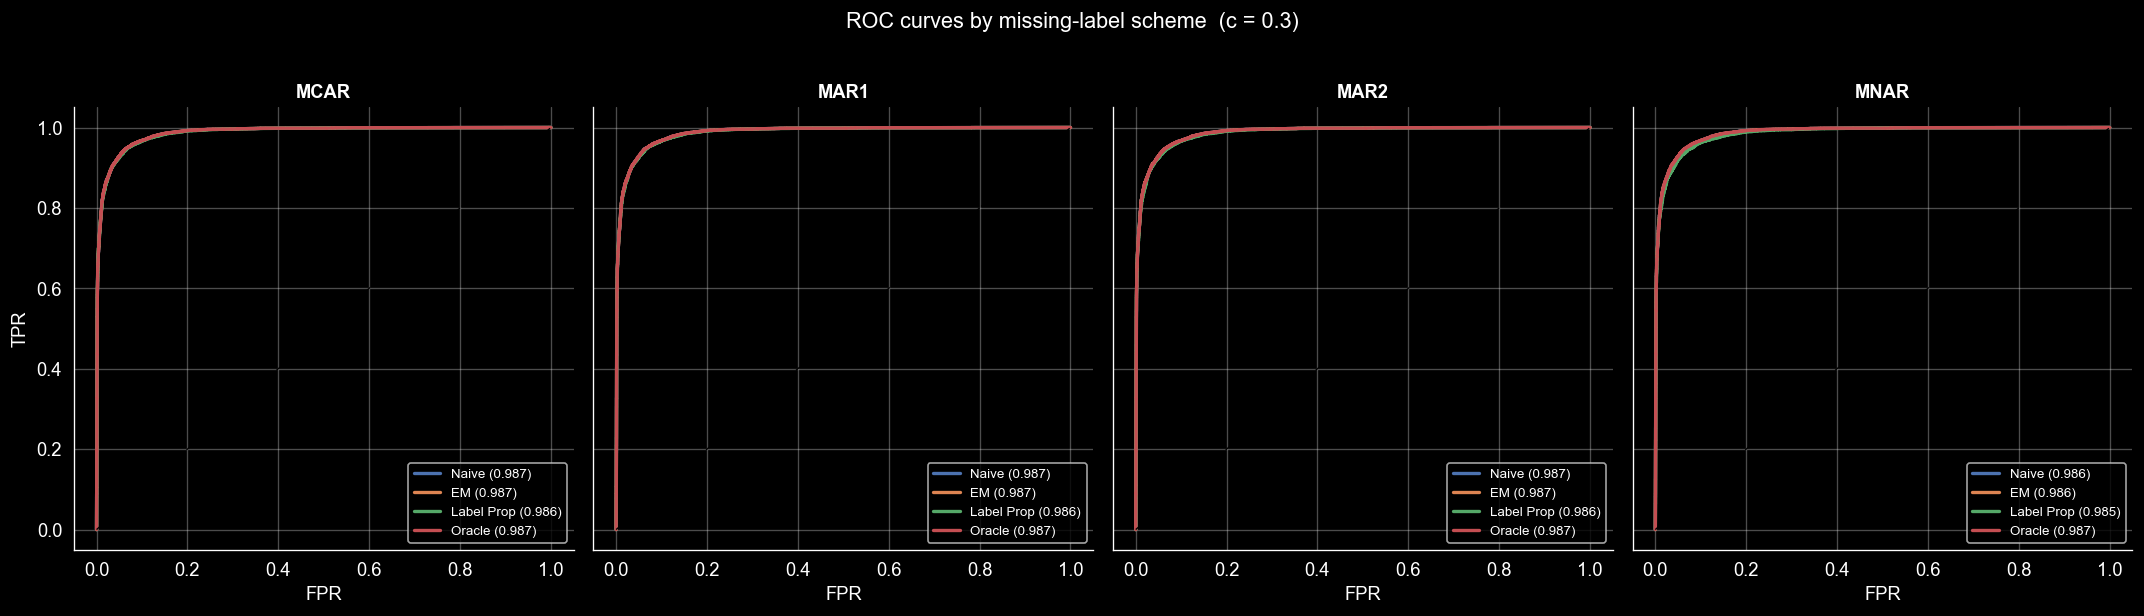

In [18]:
# ROC curves — one panel per scheme, all methods overlaid
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, scheme in zip(axes, SCHEMES):
    em_model = results_em[scheme]["model"]
    lp_model = results_lp[scheme]["model"]

    models_probas = {
        "Naive":      em_model.model_naive_.predict_proba(X_test_s),
        "EM":         em_model.predict_proba(X_test_s),
        "Label Prop": lp_model.predict_proba(X_test_s),
        "Oracle":     em_model.model_oracle_.predict_proba(X_test_s),
    }
    for mname, proba in models_probas.items():
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        ax.plot(fpr, tpr, color=PALETTE[mname], linewidth=2,
                label=f"{mname} ({auc:.3f})")
    ax.plot([0,1],[0,1],"k--", linewidth=0.8)
    ax.set_title(scheme, fontsize=11, fontweight="bold")
    ax.set_xlabel("FPR")
    ax.legend(fontsize=8)

axes[0].set_ylabel("TPR")
fig.suptitle(f"ROC curves by missing-label scheme  (c = {C_MISSING})", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

### 3.3 — Experiment 2: MCAR Sensitivity (varying c)

In [ ]:
C_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5]
sens_em, sens_lp = {}, {}

for c in C_VALUES:
    _, y_obs, _ = generate_missing(
        scheme="MCAR", X=pd.DataFrame(X_train_s, columns=feature_names),
        y=y_train, missing_rate=c, random_state=RANDOM_STATE,
    )
    n_miss = int((y_obs == -1).sum())

    for tag, method, store in [("EM", "em", sens_em), ("LP", "label_propagation", sens_lp)]:
        model = UnlabeledLogReg(
            method=method, lambda_val=BEST_LAMBDA,
            max_iter=20, tol=1e-4, fista_max_iter=1000,
            n_neighbors=10, random_state=RANDOM_STATE,
        )
        model.naive_fit(X_train_s, y_obs)
        model.oracle_fit(X_train_s, y_train)
        model.fit(X_train_s, y_obs)

        method_label = "EM" if tag == "EM" else "Label Prop"
        store[c] = {
            "Naive":      model._metrics(y_test, model.model_naive_.predict_proba(X_test_s)),
            method_label: model._metrics(y_test, model.predict_proba(X_test_s)),
            "Oracle":     model._metrics(y_test, model.model_oracle_.predict_proba(X_test_s)),
        }
    print(f"c={c:.1f}: missing={n_miss}/{len(y_obs)} ({c:.0%})")

print("Done.")

    [EM] converged at iteration 3  (Δ=2.03e-05)
c=0.1: missing=5625/56478 (10%)
    [EM] converged at iteration 4  (Δ=2.82e-05)
c=0.2: missing=11207/56478 (20%)
    [EM] converged at iteration 5  (Δ=4.41e-05)


In [ ]:
def to_sens_df(store, method_label):
    rows = []
    for c, d in store.items():
        for mname, scores in d.items():
            rows.append({"c": c, "Method": mname, **scores})
    return pd.DataFrame(rows).set_index(["c", "Method"])

df_sens_em = to_sens_df(sens_em, "EM")
df_sens_lp = to_sens_df(sens_lp, "Label Prop")

print("=== MCAR Sensitivity — EM ===")
display(df_sens_em.round(4))
print("\n=== MCAR Sensitivity — Label Propagation ===")
display(df_sens_lp.round(4))

In [ ]:
def plot_sensitivity(df_em, df_lp, c_vals):
    markers = {"Naive": "o", "EM": "s", "Label Prop": "D", "Oracle": "^"}
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    axes = axes.flatten()

    for ax, metric in zip(axes, METRICS_T3):
        # EM lines
        for mname in ["Naive", "EM", "Oracle"]:
            vals = [df_em.loc[(c, mname), metric] for c in c_vals]
            ls = "--" if mname == "Oracle" else "-"
            ax.plot(c_vals, vals, ls + markers[mname],
                    color=PALETTE[mname], linewidth=2, markersize=6,
                    label=f"{mname} (EM)" if mname not in ("Naive","Oracle") else mname)
        # LP line
        for mname in ["Label Prop"]:
            vals = [df_lp.loc[(c, mname), metric] for c in c_vals]
            ax.plot(c_vals, vals, "-" + markers[mname],
                    color=PALETTE[mname], linewidth=2, markersize=6, label="Label Prop")

        ax.set_title(metric, fontsize=11, fontweight="bold")
        ax.set_xlabel("Missingness rate  c")
        ax.set_ylabel("Score")
        ax.set_xticks(c_vals)
        ax.set_ylim(bottom=max(0, ax.get_ylim()[0] - 0.02))
        ax.legend(fontsize=8)

    fig.suptitle("MCAR Sensitivity — performance vs missingness rate  c", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

plot_sensitivity(df_sens_em, df_sens_lp, C_VALUES)

### 3.4 — Key Findings

| Scheme | Observation |
|--------|-------------|
| **MCAR** | All methods track each other closely (ROC AUC gap < 0.002). At c = 0.3 the labeled set (~39k rows) already provides a strong signal; the unlabeled data adds little. |
| **MAR1 / MAR2** | Naive is competitive. The missingness depends on X in a way correlated with the outcome, so unlabeled observations are biased samples — EM can reinforce this bias through iterative re-fitting. |
| **MNAR** | Most challenging. Upsets (Y=1) are systematically more likely to be missing, creating a label-imbalance artifact in the training set. Oracle remains strong; Naive and semi-supervised methods degrade, with Label Propagation hurt more because the graph structure reflects the biased label distribution. |
| **c sensitivity** | Performance degrades smoothly as c increases 0.1 → 0.5. Oracle is constant (no effect). The gap Naive–Oracle widens with c, as expected. EM and Label Prop sit between the two baselines. |

**Discussion — FISTA vs sklearn:**  Both implementations produce nearly identical test metrics and coefficient vectors (scatter lies on the y=x line). Slight numerical differences arise from different convergence criteria and internal solvers. The L1 penalty correctly zeroes out less informative features (e.g. `height_diff`, `avg_age`) while keeping the most predictive ones (`rank_diff`, `log_rank_ratio`, `first_won_pct_diff`).

---
## Summary

In [ ]:
print("=" * 65)
print("TASK 2 — FISTA vs sklearn (test set)")
print("=" * 65)
display(t2_results)

print("\n" + "=" * 65)
print("TASK 3 — Experiment 1: Four schemes (c=0.3) | EM")
print("=" * 65)
display(df_em.round(4))

print("\n" + "=" * 65)
print("TASK 3 — Experiment 1: Four schemes (c=0.3) | Label Propagation")
print("=" * 65)
display(df_lp.round(4))

print("\n" + "=" * 65)
print("TASK 3 — Experiment 2: MCAR sensitivity | EM")
print("=" * 65)
display(df_sens_em.round(4))

print("\n" + "=" * 65)
print("TASK 3 — Experiment 2: MCAR sensitivity | Label Propagation")
print("=" * 65)
display(df_sens_lp.round(4))